# EDA — Chương trình đào tạo UIT

Khám phá: mỗi khoa × khóa có bao nhiêu TC, bắt buộc/tự chọn bao nhiêu, cấu trúc từng khối kiến thức ra sao.

In [19]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path("..").resolve()
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Load tất cả programs ─────────────────────────────────────────────────────
rows = []
for p in sorted((ROOT / "data" / "programs").glob("**/*.json")):
    d = json.loads(p.read_text())
    cohort, major, ptype = d["cohort"], d["major"], d["program_type"]
    courses = d.get("courses", [])

    tc_mand = sum(c.get("credits") or 0 for c in courses if c.get("is_mandatory", True))
    tc_elec = sum(c.get("credits") or 0 for c in courses if not c.get("is_mandatory", True))

    # TC per block
    blocks = {}
    for b in d.get("knowledge_blocks", []):
        bcs = [c for c in courses if c.get("block_id") == b["block_id"]]
        blocks[b["block_name"]] = {
            "required_credits": b.get("required_credits"),
            "is_elective": b.get("is_elective", False),
            "n_courses": len(bcs),
            "tc_sum": sum(c.get("credits") or 0 for c in bcs),
        }

    rows.append({
        "cohort":       cohort,
        "major":        major,
        "program_type": ptype,
        "total_credits": d.get("total_credits"),
        "n_courses":    len(courses),
        "tc_mandatory": tc_mand,
        "tc_elective":  tc_elec,
        "n_blocks":     len(d.get("knowledge_blocks", [])),
        "_blocks":      blocks,
        "_courses":     courses,
    })

df = pd.DataFrame(rows)
std = df[df["program_type"] == "standard"].copy()

print(f"Tổng: {len(df)} programs  |  {df['cohort'].nunique()} khóa  |  {df['major'].nunique()} ngành")
print(f"Loại hình: {df['program_type'].value_counts().to_dict()}")
df[["cohort","major","program_type","total_credits","tc_mandatory","tc_elective","n_courses"]].head(8)

Tổng: 203 programs  |  14 khóa  |  12 ngành
Loại hình: {'standard': 120, 'high_quality': 40, 'talent': 20, 'second_degree': 7, 'transfer': 7, 'distance': 3, 'second_degree_distance': 3, 'transfer_distance': 3}


,cohort,major,program_type,total_credits,tc_mandatory,tc_elective,n_courses
0,K2012,ATTT,standard,148.0,195,0,56
1,K2012,CNTT,standard,138.0,212,0,63
2,K2012,HTTT,standard,NaN,188,0,56
3,K2012,KHMT,standard,NaN,277,0,77
4,K2012,KTMT,standard,NaN,194,0,62
5,K2012,KTPM,standard,NaN,153,78,73
6,K2012,MMT&TTDL,standard,148.0,164,0,52
7,K2013,ATTT,standard,148.0,195,0,56


## 1. Tổng TC bắt buộc vs tự chọn — từng ngành từng khóa

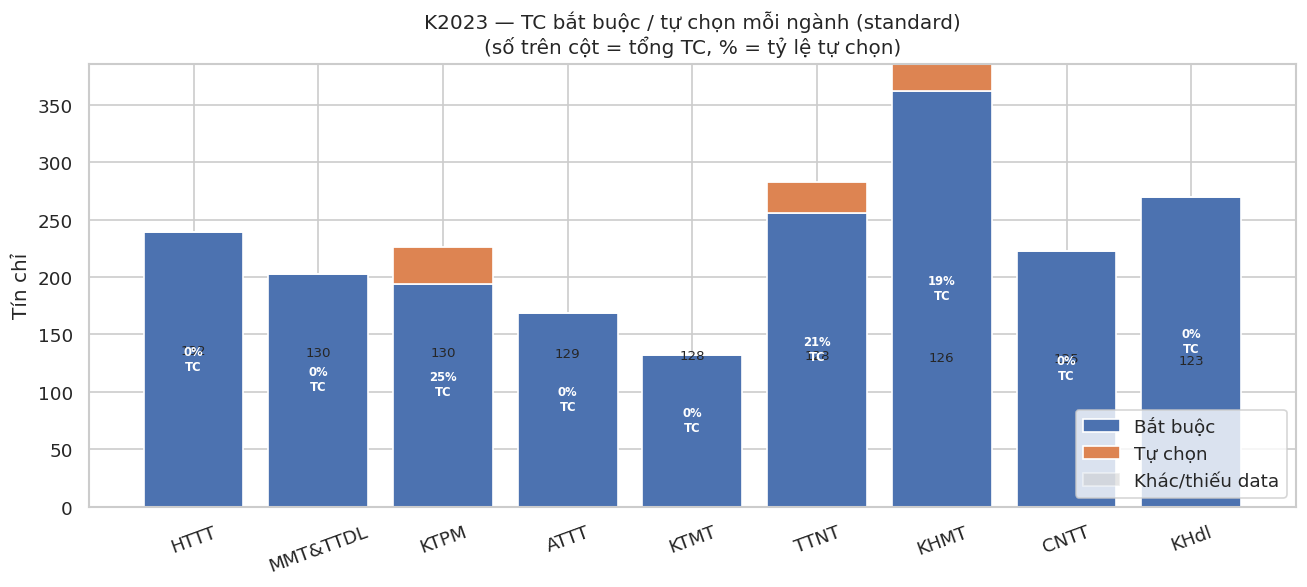

   major  total_credits  tc_mandatory  tc_elective  pct_elec
    HTTT          132.0           239            0       0.0
MMT&TTDL          130.0           203            0       0.0
    KTPM          130.0           194           32      24.6
    ATTT          129.0           169            0       0.0
    KTMT          128.0           132            0       0.0
    TTNT          128.0           256           27      21.1
    KHMT          126.0           362           24      19.0
    CNTT          125.0           223            0       0.0
    KHdl          123.0           270            0       0.0


In [20]:
# Bảng tổng hợp: cohort × major — TC bắt buộc / tự chọn / tổng
summary = (
    std.dropna(subset=["total_credits"])
    .groupby(["major", "cohort"])[["total_credits", "tc_mandatory", "tc_elective"]]
    .first()
    .reset_index()
)

# Lấy snapshot K2023 để nhìn nhanh
snap = summary[summary["cohort"] == "K2023"].sort_values("total_credits", ascending=False).reset_index(drop=True)
snap["tc_other"] = snap["total_credits"] - snap["tc_mandatory"] - snap["tc_elective"]
snap["pct_elec"] = (snap["tc_elective"] / snap["total_credits"] * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
majors = snap["major"].tolist()
x = range(len(majors))

ax.bar(x, snap["tc_mandatory"], label="Bắt buộc",  color="#4C72B0")
ax.bar(x, snap["tc_elective"],  bottom=snap["tc_mandatory"], label="Tự chọn", color="#DD8452")
ax.bar(x, snap["tc_other"].clip(lower=0),
       bottom=snap["tc_mandatory"] + snap["tc_elective"],
       label="Khác/thiếu data", color="#cccccc", alpha=0.5)

for i, row in snap.iterrows():
    ax.text(i, row["total_credits"] + 1, f'{row["total_credits"]:.0f}', ha="center", fontsize=8)
    ax.text(i, row["tc_mandatory"] / 2, f'{row["pct_elec"]:.0f}%\nTC', ha="center",
            fontsize=7, color="white", fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(majors, rotation=20)
ax.set_ylabel("Tín chỉ")
ax.set_title("K2023 — TC bắt buộc / tự chọn mỗi ngành (standard)\n(số trên cột = tổng TC, % = tỷ lệ tự chọn)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(snap[["major","total_credits","tc_mandatory","tc_elective","pct_elec"]].to_string(index=False))

## 2. Xu hướng tổng TC theo khóa — ngành có thay đổi không?

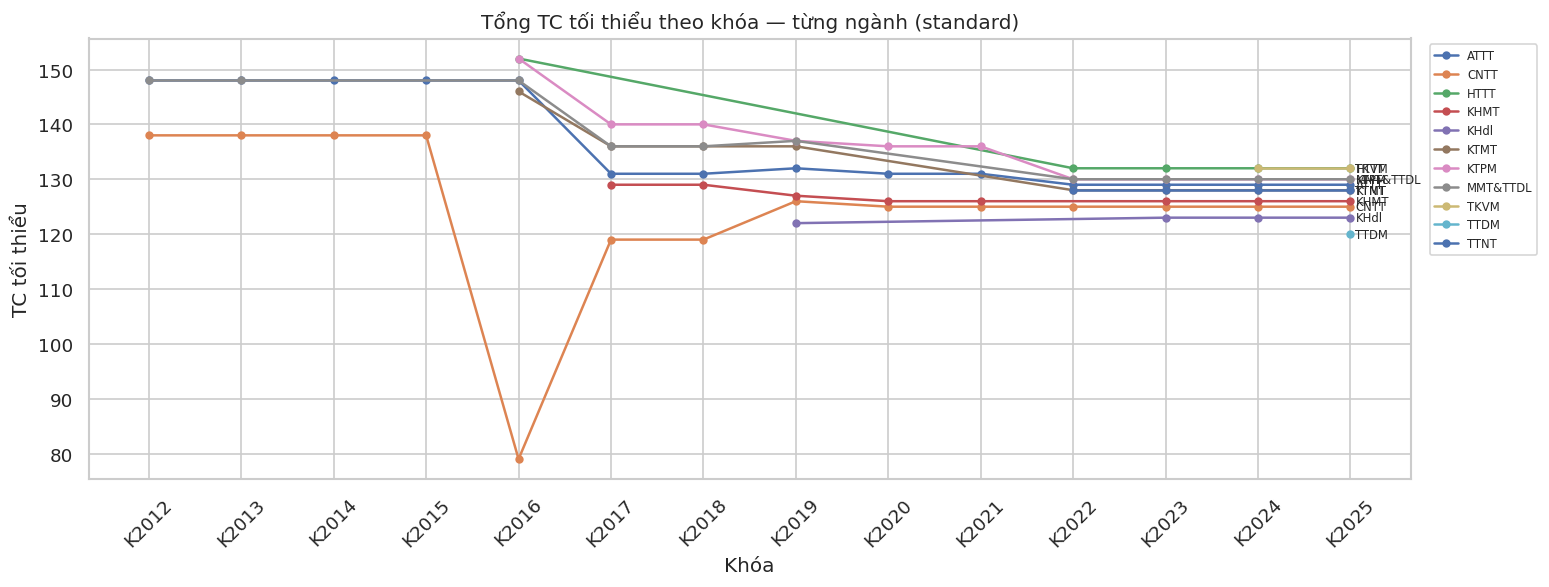

Thay đổi TC: K2017 → K2023
cohort    K2017  K2023  delta
major                        
KTPM      140.0  130.0  -10.0
KTMT      136.0  128.0   -8.0
MMT&TTDL  136.0  130.0   -6.0
KHMT      129.0  126.0   -3.0
ATTT      131.0  129.0   -2.0
CNTT      119.0  125.0    6.0


In [21]:
pivot_tc = (
    summary.pivot_table(index="cohort", columns="major", values="total_credits")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for col in pivot_tc.columns:
    s = pivot_tc[col].dropna()
    ax.plot(s.index, s.values, marker="o", label=col, linewidth=1.5, markersize=4)
    # label cuối
    ax.annotate(col, xy=(s.index[-1], s.values[-1]),
                xytext=(3, 0), textcoords="offset points", fontsize=7, va="center")

ax.set_title("Tổng TC tối thiểu theo khóa — từng ngành (standard)")
ax.set_xlabel("Khóa")
ax.set_ylabel("TC tối thiểu")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

# Bảng: TC thay đổi nhiều nhất giữa K2017→K2023
recent = summary[summary["cohort"].isin(["K2017","K2023"])].pivot_table(
    index="major", columns="cohort", values="total_credits"
).dropna()
if not recent.empty and "K2017" in recent and "K2023" in recent:
    recent["delta"] = recent["K2023"] - recent["K2017"]
    print("Thay đổi TC: K2017 → K2023")
    print(recent.sort_values("delta").to_string())

## 3. Cấu trúc khối kiến thức — một ngành cụ thể

Chọn một ngành × khóa để xem chi tiết từng khối: tên, TC yêu cầu, bắt buộc hay tự chọn.

K2023 — KTPM — standard
Total TC tối thiểu: 130.0  |  Môn: 70  |  Khối: 8
                                                 Khối TC yêu cầu Tự chọn  Số môn  Tổng TC môn
          3.3 Khối kiến thức giáo dục đại cương         43              17           43
         3.4.1 Nhóm các môn học cơ sở ngành : 49TC          —              19           69
3.4.2 Nhóm các môn học tự chọn chuyên ngành: 14TC          —       ✓      25           82
                       3.4.3 Nhóm các môn học khác          —               1            2
                          3.5.1 Thực tập doanh nghiệp          —               1            2
                         3.5.2 Nhóm các môn học đồ án          —               2            4
                           3.5.3 Khóa luận tốt nghiệp          —               1           10
       3.5.4 Nhóm các môn học chuyên đề tốt nghiệp          —               4           14


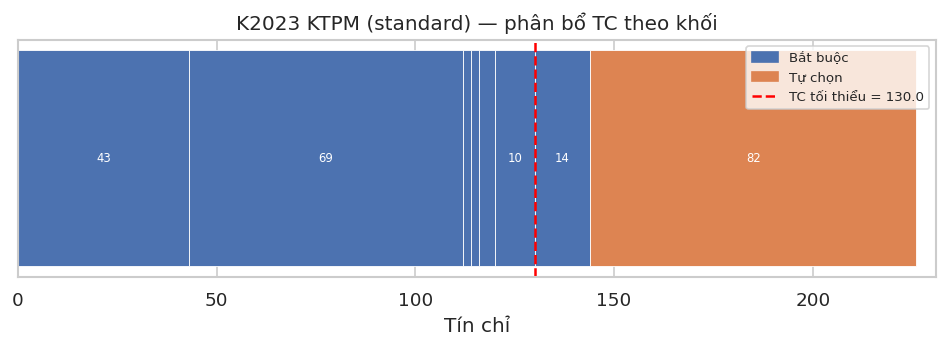

In [22]:
def show_program(cohort: str, major: str, program_type: str = "standard"):
    row = df[
        (df["cohort"] == cohort) & (df["major"] == major) &
        (df["program_type"] == program_type)
    ]
    if row.empty:
        print(f"Không tìm thấy {cohort}/{major}/{program_type}")
        return

    row = row.iloc[0]
    blocks = row["_blocks"]
    total_tc = row["total_credits"] or 0
    print(f"{'='*60}")
    print(f"{cohort} — {major} — {program_type}")
    print(f"Total TC tối thiểu: {total_tc}  |  Môn: {row['n_courses']}  |  Khối: {row['n_blocks']}")
    print(f"{'='*60}")

    block_data = []
    for bname, binfo in blocks.items():
        block_data.append({
            "Khối": bname[:55],
            "TC yêu cầu": binfo["required_credits"] or "—",
            "Tự chọn": "✓" if binfo["is_elective"] else "",
            "Số môn": binfo["n_courses"],
            "Tổng TC môn": binfo["tc_sum"],
        })
    bdf = pd.DataFrame(block_data)
    print(bdf.to_string(index=False))

    if total_tc:
        # Stacked bar
        fig, ax = plt.subplots(figsize=(8, 3))
        req_bnames, req_vals, elec_vals = [], [], []
        for bname, binfo in blocks.items():
            short = bname[:40]
            if binfo["is_elective"]:
                elec_vals.append((short, binfo["tc_sum"]))
            else:
                req_vals.append((short, binfo["tc_sum"]))

        y, labels = 0, []
        for name, val in req_vals:
            ax.barh(0, val, left=y, color="#4C72B0", edgecolor="white", linewidth=0.5)
            if val >= 5:
                ax.text(y + val/2, 0, f"{val}", ha="center", va="center",
                        color="white", fontsize=7)
            y += val
            labels.append(name)
        for name, val in elec_vals:
            ax.barh(0, val, left=y, color="#DD8452", edgecolor="white", linewidth=0.5)
            if val >= 5:
                ax.text(y + val/2, 0, f"{val}", ha="center", va="center",
                        color="white", fontsize=7)
            y += val

        ax.axvline(total_tc, color="red", linestyle="--", linewidth=1.5,
                   label=f"TC tối thiểu = {total_tc}")
        ax.set_xlim(0, max(y, total_tc) + 5)
        ax.set_yticks([])
        ax.set_xlabel("Tín chỉ")
        ax.set_title(f"{cohort} {major} ({program_type}) — phân bổ TC theo khối")
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color="#4C72B0", label="Bắt buộc"),
            Patch(color="#DD8452", label="Tự chọn"),
        ] + [ax.get_lines()[0]], fontsize=8)
        plt.tight_layout()
        plt.show()

# ── Thử với một vài ngành ─────────────────────────────────────────────────────
show_program("K2023", "KTPM")

K2025 — TTNT — standard
Total TC tối thiểu: 128.0  |  Môn: 86  |  Khối: 5
                                            Khối TC yêu cầu Tự chọn  Số môn  Tổng TC môn
     5.2 Khối kiến thức giáo dục đại cương         45              18           45
5.3.1 Các môn học cơ sở ngành Trí tuệ nhân tạo         57              20           72
                5.3.2 Các môn học tự chọn ngành          8       ✓      23           87
           5.3.3 Các môn học tự chọn liên ngành          8       ✓      17           63
                   5.4 Khối kiến thức tốt nghiệp          —               8           46


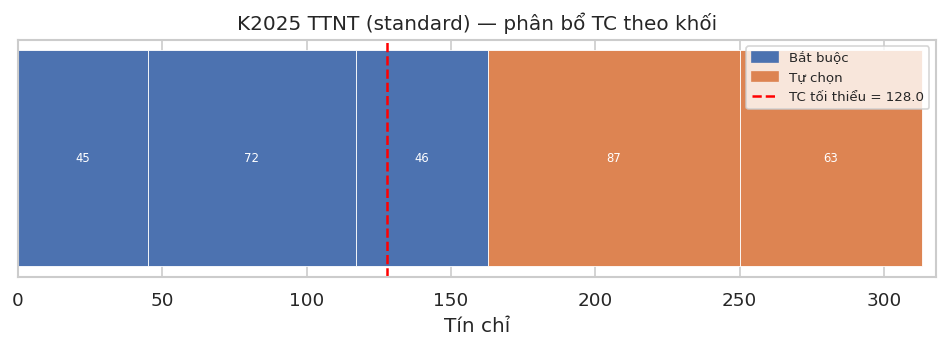

In [23]:
show_program("K2025", "TTNT")

## 4. So sánh nhanh nhiều ngành cùng khóa — heatmap TC theo khối

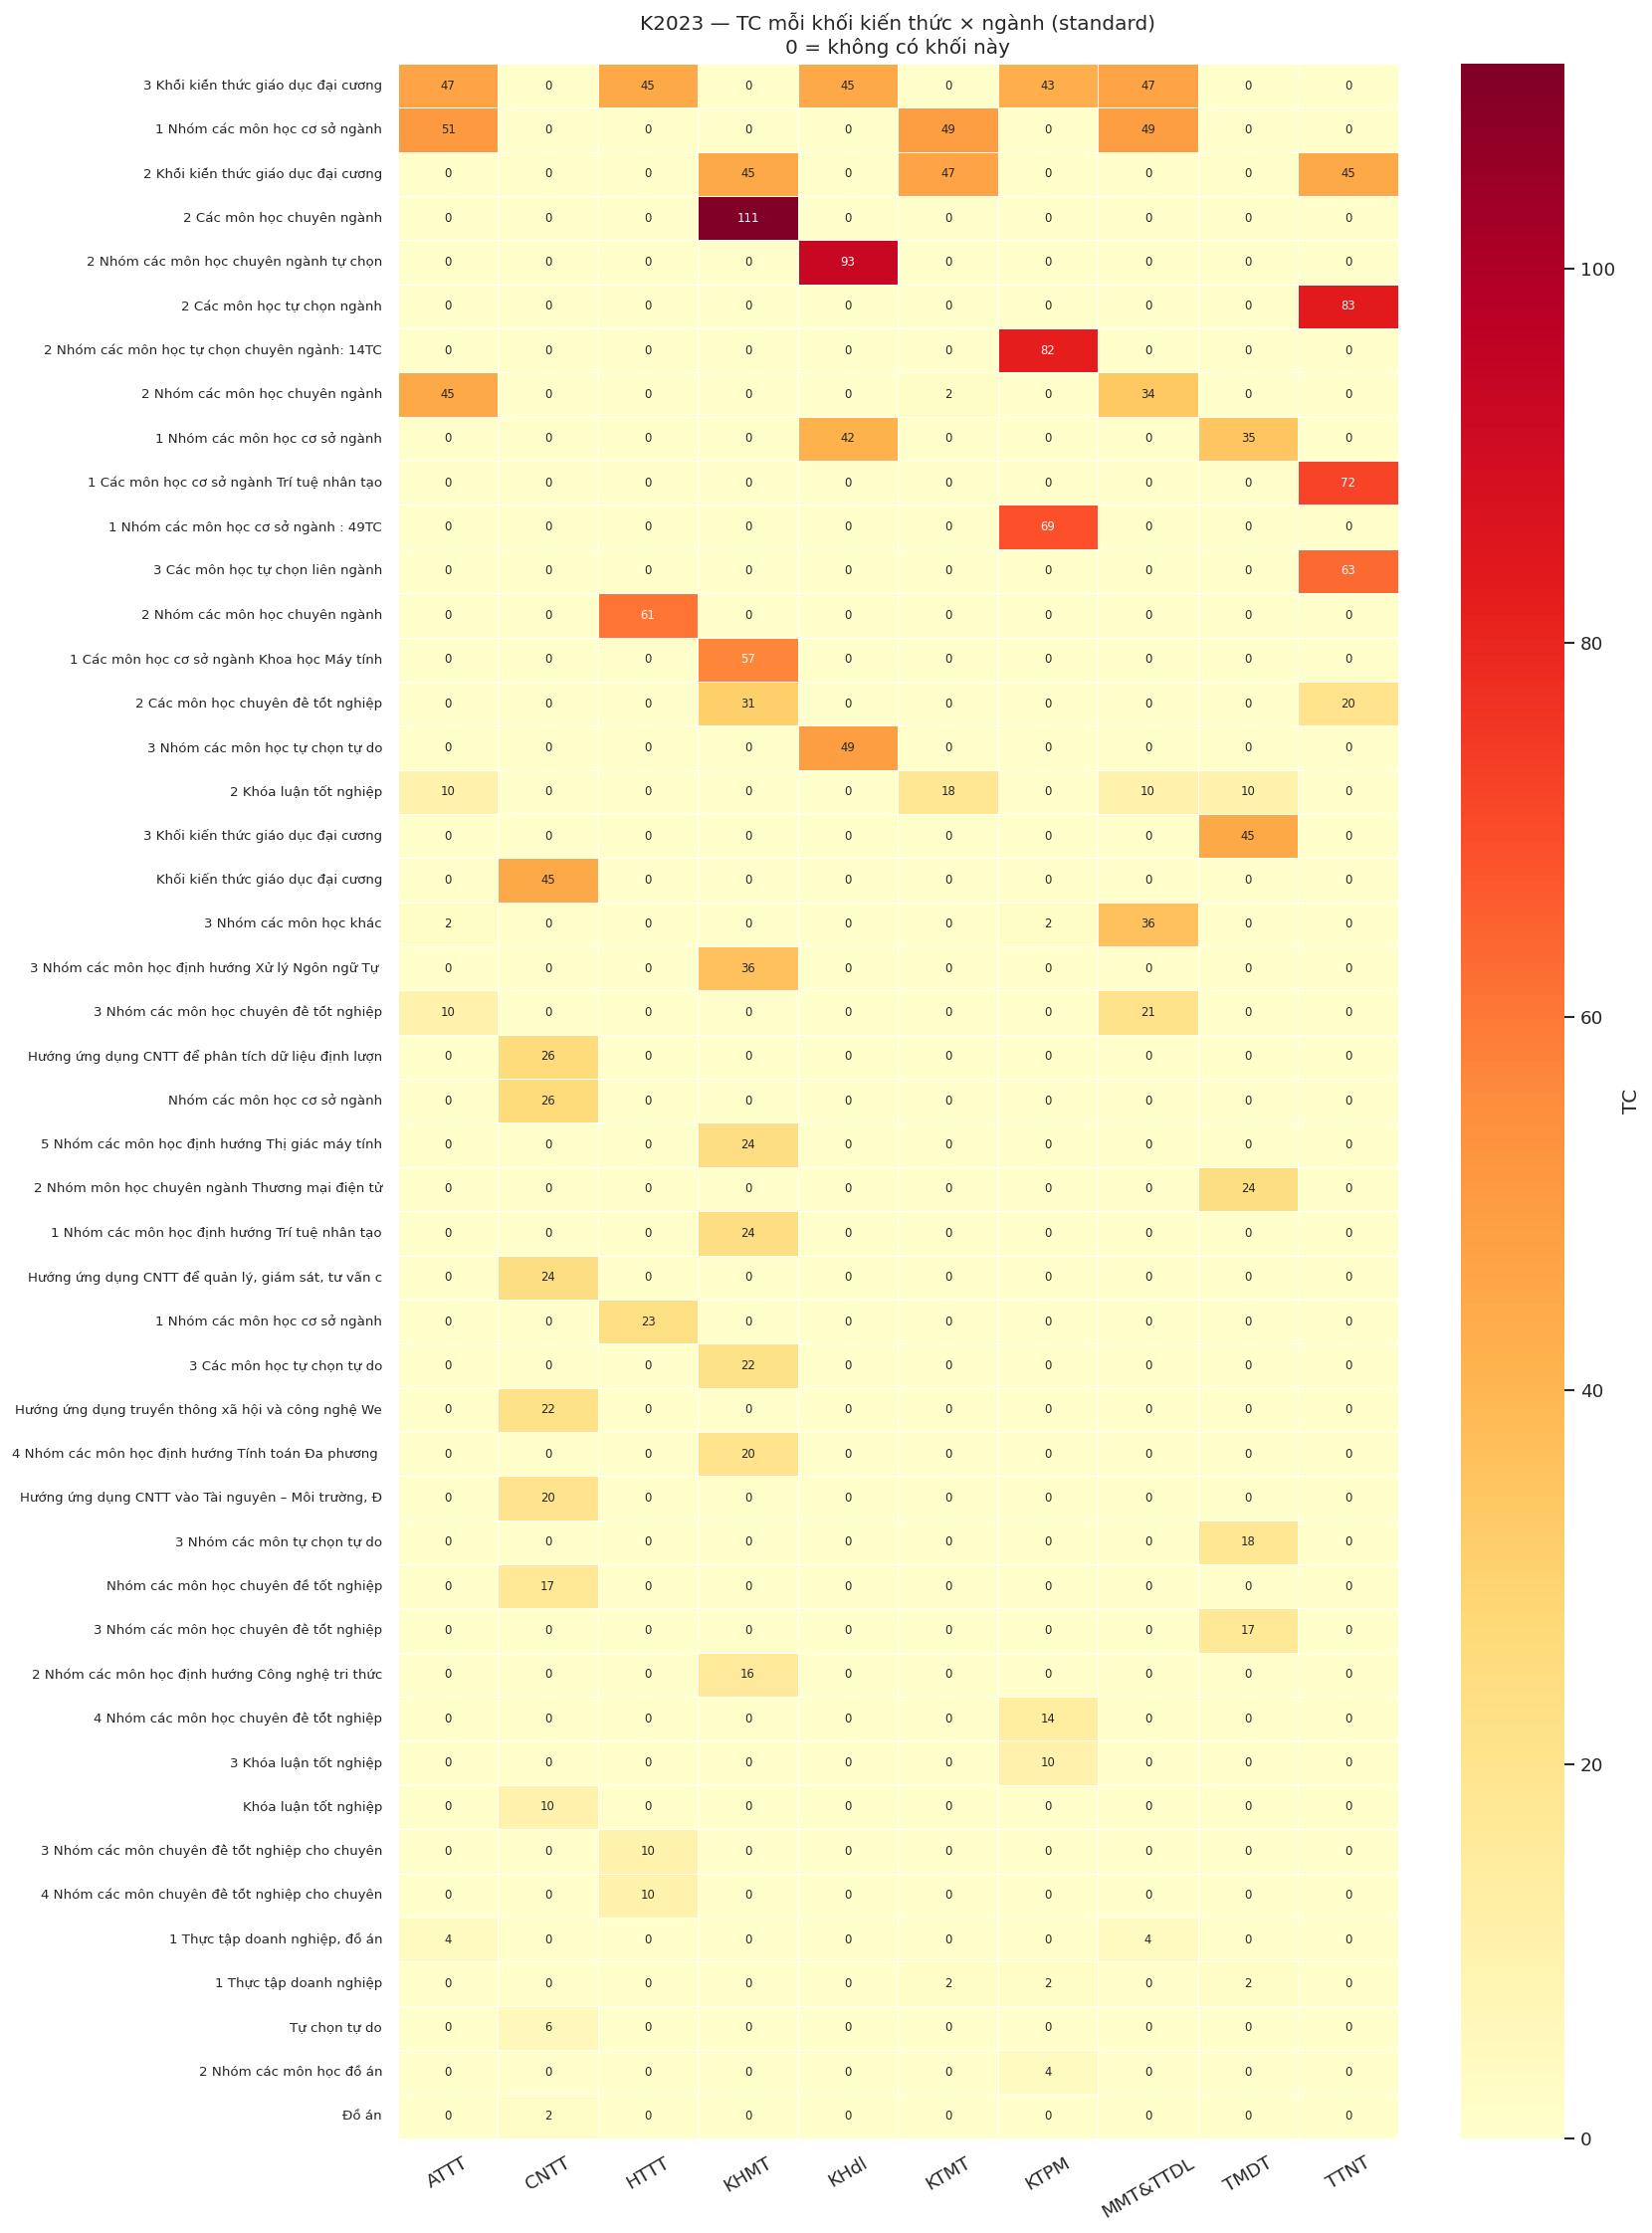

In [24]:
TARGET_COHORT = "K2023"

# Normalize block names across majors: strip leading numbering for grouping
import re

def normalize_block(name: str) -> str:
    # Strip leading "3.1. ", "1.2. " etc. and truncate
    name = re.sub(r'^\d+(\.\d+)*\.\s*', '', name).strip()
    return name[:50]

heat_rows = []
for _, row in df[(df["cohort"] == TARGET_COHORT) & (df["program_type"] == "standard")].iterrows():
    for bname, binfo in row["_blocks"].items():
        heat_rows.append({
            "major":     row["major"],
            "block":     normalize_block(bname),
            "tc_sum":    binfo["tc_sum"],
            "is_elec":   binfo["is_elective"],
        })

heat_df = pd.DataFrame(heat_rows)

# Pivot: major × block, value = tc_sum
pivot = heat_df.pivot_table(index="block", columns="major", values="tc_sum",
                             aggfunc="sum", fill_value=0)
# Keep blocks with any TC > 0
pivot = pivot[pivot.sum(axis=1) > 0]
# Sort by total TC descending
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.4)))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.4, linecolor="white",
            annot=True, fmt=".0f", annot_kws={"size": 7},
            cbar_kws={"label": "TC"})
ax.set_title(f"{TARGET_COHORT} — TC mỗi khối kiến thức × ngành (standard)\n0 = không có khối này")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 5. Danh sách môn theo ngành × khóa — tra cứu nhanh

In [25]:
def list_courses(cohort: str, major: str, program_type: str = "standard",
                 only_mandatory: bool = False):
    """In danh sách môn của một chương trình."""
    row = df[(df["cohort"]==cohort)&(df["major"]==major)&(df["program_type"]==program_type)]
    if row.empty:
        print("Không tìm thấy")
        return
    row = row.iloc[0]
    courses = row["_courses"]
    if only_mandatory:
        courses = [c for c in courses if c.get("is_mandatory", True)]

    out = []
    for c in courses:
        out.append({
            "ID": c["course_id"],
            "Tên môn": c.get("course_name","")[:40],
            "TC": c.get("credits"),
            "Khối": c.get("block_name","")[:30],
            "Bắt buộc": "✓" if c.get("is_mandatory", True) else "—",
            "HK": c.get("semester") or "—",
        })
    result = pd.DataFrame(out)
    print(f"{cohort} — {major} ({program_type})  |  {len(result)} môn  "
          f"| {'chỉ bắt buộc' if only_mandatory else 'tất cả'}")
    return result

# Xem K2023 CNTT standard — chỉ bắt buộc
list_courses("K2023", "CNTT", only_mandatory=True)

K2023 — CNTT (standard)  |  68 môn  | chỉ bắt buộc


,ID,Tên môn,TC,Khối,Bắt buộc,HK
0,SS003,Tư tưởng Hồ Chí Minh,2.0,3.3. Khối kiến thức giáo dục đ,✓,—
1,SS007,Triết học Mác – Lênin,3.0,3.3. Khối kiến thức giáo dục đ,✓,—
2,SS008,Kinh tế chính trị Mác – Lênin,2.0,3.3. Khối kiến thức giáo dục đ,✓,—
3,SS009,Chủ nghĩa xã hội khoa học,2.0,3.3. Khối kiến thức giáo dục đ,✓,—
4,SS010,Lịch sử Đảng Cộng sản Việt Nam,2.0,3.3. Khối kiến thức giáo dục đ,✓,—
...,...,...,...,...,...,...
63,IE401,Tin-Sinh học,3.0,3.5.3. Nhóm các môn học chuyên,✓,—
64,IE402,Hệ thống thông tin địa lý 3 chiều,4.0,3.5.3. Nhóm các môn học chuyên,✓,—
65,IE403,Khai thác dữ liệu truyền thông xã hội,3.0,3.5.3. Nhóm các môn học chuyên,✓,—
66,IE405,Công nghệ phân tích dữ liệu lớn,4.0,3.5.3. Nhóm các môn học chuyên,✓,—


In [26]:
# So sánh hai khóa cùng ngành — môn nào thêm/bớt
def diff_programs(cohort_a: str, cohort_b: str, major: str, program_type: str = "standard"):
    def get_ids(cohort):
        row = df[(df["cohort"]==cohort)&(df["major"]==major)&(df["program_type"]==program_type)]
        if row.empty: return {}
        return {c["course_id"]: c.get("course_name","") for c in row.iloc[0]["_courses"]}

    a, b = get_ids(cohort_a), get_ids(cohort_b)
    added   = {k: b[k] for k in b if k not in a}
    removed = {k: a[k] for k in a if k not in b}
    kept    = len(set(a) & set(b))

    print(f"{major}: {cohort_a} → {cohort_b}")
    print(f"  Giữ nguyên: {kept} môn")
    print(f"  Thêm ({len(added)}): {', '.join(f'{k}({v[:20]})' for k,v in list(added.items())[:8])}")
    print(f"  Bỏ  ({len(removed)}): {', '.join(f'{k}({v[:20]})' for k,v in list(removed.items())[:8])}")

diff_programs("K2020", "K2023", "CNTT")
print()
diff_programs("K2020", "K2023", "KTPM")
print()
diff_programs("K2022", "K2025", "TTNT")

CNTT: K2020 → K2023
  Giữ nguyên: 61 môn
  Thêm (7): PE231(Giáo dục thể chất 1), PE232(Giáo dục thể chất 2), IE108(Phân tích thiết kế p), BUS1125(Khởi nghiệp kinh doa), IE231(Quản trị doanh nghiệ), TLH025(Tâm lý học nhân cách), IE310(Tư duy thiết kế)
  Bỏ  (3): PE012(Giáo dục thể chất), SE104(Nhập môn công nghệ p), IE202(Quản trị doanh nghiệ)

KTPM: K2020 → K2023
  Giữ nguyên: 66 môn
  Thêm (4): PE231(Giáo dục thể chất 1), PE232(Giáo dục thể chất 2), SE501(Thực tập doanh nghiệ), SE505(Khóa luận tốt nghiệp)
  Bỏ  (12): PE012(Giáo dục thể chất), SE402(Điện toán đám mây (1), CS519(Phương pháp luận sán), IE202(Quản trị doanh nghiệ), IE406(Nhập môn ẩn thông ti), IS341(Khởi nghiệp (2)), IS252(Khai thác dữ liệu (1), IS254(Hệ hỗ trợ quyết định)

TTNT: K2022 → K2025
  Giữ nguyên: 76 môn
  Thêm (10): PE231(Giáo dục thể chất 1), PE232(Giáo dục thể chất 2), AI002(Tư duy Trí tuệ nhân ), CS337(Xử lý âm thanh và ti), AI301(Khởi nghiệp và sáng ), AI302(Kỹ thuật viết báo cá), CS317(Phát triển và vận hà